## 1. Importation des bibliothèques

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuration pour l'affichage
plt.rcParams['figure.figsize'] = (15, 5)

## 2. Chargement de l'image

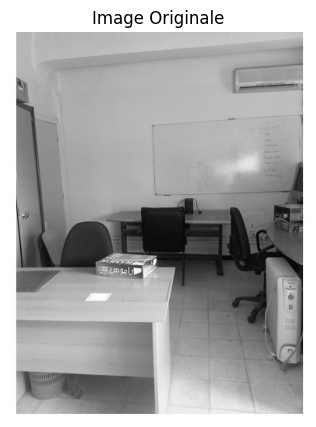

In [11]:
# Lecture de l'image
img_path = "im1.jpg"
image_c = cv2.imread(img_path)
image = cv2.cvtColor(image_c, cv2.COLOR_BGR2GRAY)

# Affichage de l'image originale
plt.figure()
plt.imshow(image, cmap='gray')
plt.title('Image Originale')
plt.axis('off')
plt.show()

## 3. Définition des paramètres

- **sigma** : écart-type du filtre gaussien (contrôle l'intensité du flou)
- **n** : nombre d'itérations
- **kernel_size** : taille du noyau de convolution

In [12]:
# Paramètres
sigma = 2
n = 10
kernel_size = (3, 3)

print(f"Paramètres :")
print(f"  - Sigma : {sigma}")
print(f"  - Nombre d'itérations : {n}")
print(f"  - Taille du noyau : {kernel_size}")

Paramètres :
  - Sigma : 2
  - Nombre d'itérations : 10
  - Taille du noyau : (3, 3)


## 4. Application de la convolution itérative

In [13]:
# Initialisation: première convolution g(x,y) = f(x,y) * G_sigma
g = cv2.GaussianBlur(image, kernel_size, sigma, 0, cv2.BORDER_DEFAULT)

# Sauvegarde des résultats intermédiaires pour visualisation
results = [image.copy(), g.copy()]
labels = ['Original', 'Iteration 0']

print(f"Application du filtre Gaussien (sigma={sigma})")
print(f"Iteration 0 : Convolution initiale")

# Boucle itérative: For i=1 to n
for i in range(1, n + 1):
    g = cv2.GaussianBlur(g, kernel_size, sigma, 0, cv2.BORDER_DEFAULT)
    print(f"Iteration {i} : Convolution appliquée")
    
    # Sauvegarder certaines itérations pour visualisation
    if i in [1, 2, n]:
        results.append(g.copy())
        labels.append(f'Iteration {i}')

print(f"\nTraitement terminé !")

Application du filtre Gaussien (sigma=2)
Iteration 0 : Convolution initiale
Iteration 1 : Convolution appliquée
Iteration 2 : Convolution appliquée
Iteration 3 : Convolution appliquée
Iteration 4 : Convolution appliquée
Iteration 5 : Convolution appliquée
Iteration 6 : Convolution appliquée
Iteration 7 : Convolution appliquée
Iteration 8 : Convolution appliquée
Iteration 9 : Convolution appliquée
Iteration 10 : Convolution appliquée

Traitement terminé !


## 5. Visualisation des résultats

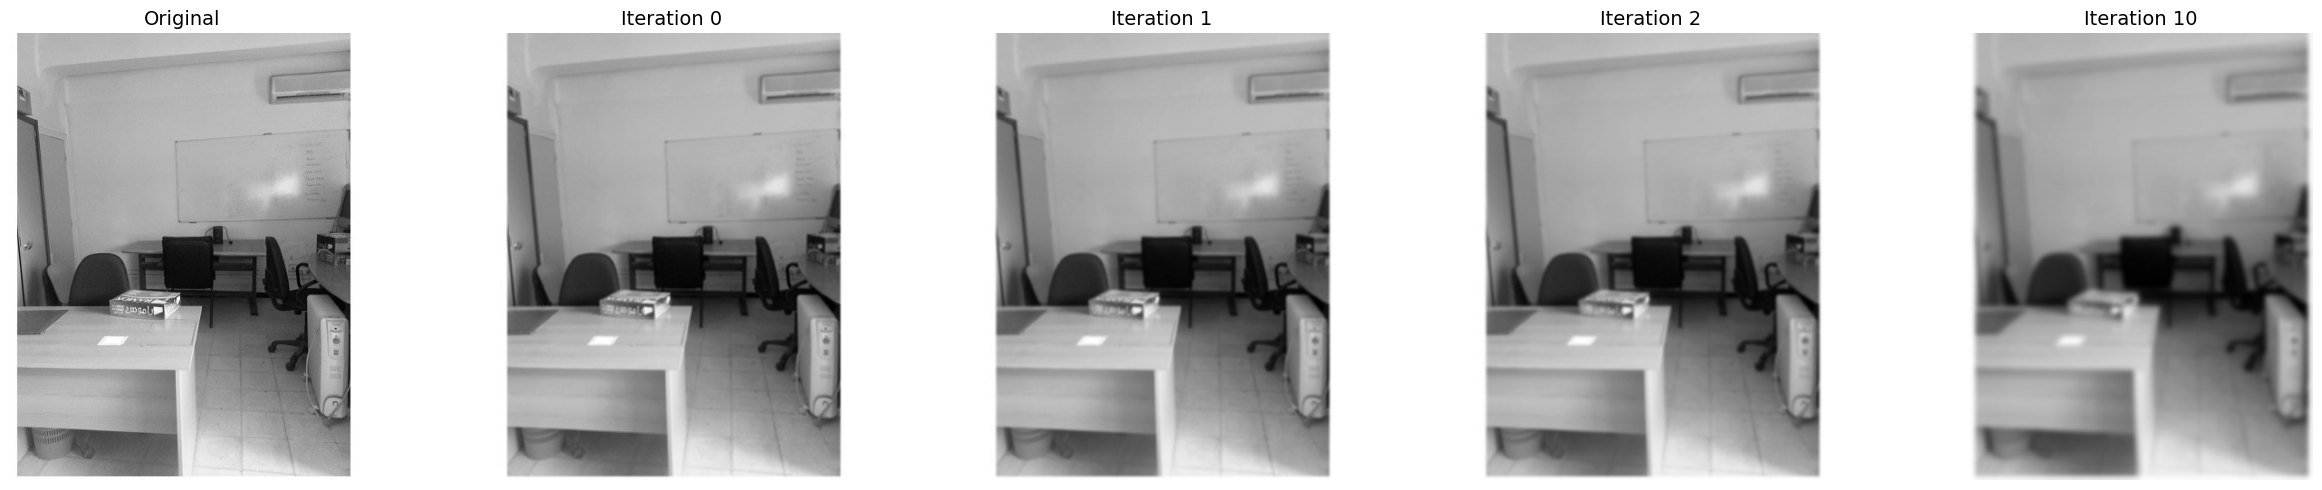

In [14]:
# Affichage comparatif
num_images = len(results)
fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))

for idx, (img, label) in enumerate(zip(results, labels)):
    if num_images > 1:
        ax = axes[idx]
    else:
        ax = axes
    
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Analyse : Relation mathématique

Appliquer $(n+1)$ convolutions avec $\sigma$ est approximativement équivalent à une convolution avec :

$$\sigma_{eq} = \sigma \sqrt{n+1}$$

Sigma équivalent théorique : 6.63

Cela signifie que 11 convolutions avec sigma=2
≈ 1 convolution avec sigma=6.63


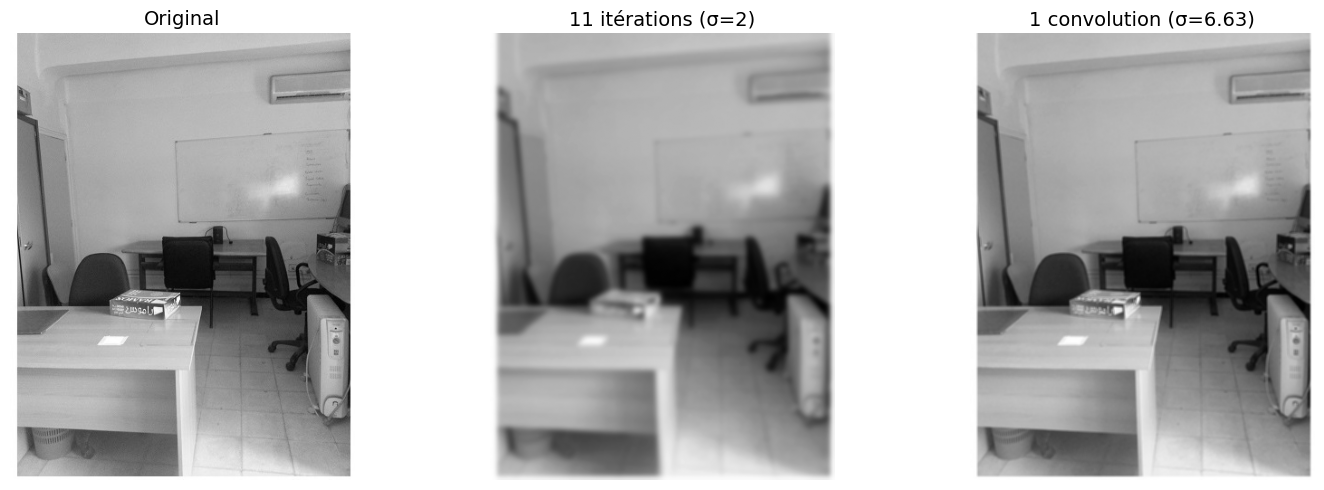


Différence moyenne entre les deux méthodes : 4.0857
Différence maximale : 100.0000


In [15]:
# Calcul du sigma équivalent
sigma_equivalent = sigma * np.sqrt(n + 1)
print(f"Sigma équivalent théorique : {sigma_equivalent:.2f}")
print(f"\nCela signifie que {n+1} convolutions avec sigma={sigma}")
print(f"≈ 1 convolution avec sigma={sigma_equivalent:.2f}")

# Vérification : une seule convolution avec sigma équivalent
g_direct = cv2.GaussianBlur(image, kernel_size, sigma_equivalent, 0, cv2.BORDER_DEFAULT)

# Comparaison visuelle
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original', fontsize=14)
axes[0].axis('off')

axes[1].imshow(g, cmap='gray')
axes[1].set_title(f'{n+1} itérations (σ={sigma})', fontsize=14)
axes[1].axis('off')

axes[2].imshow(g_direct, cmap='gray')
axes[2].set_title(f'1 convolution (σ={sigma_equivalent:.2f})', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Calcul de la différence
difference = np.abs(g.astype(float) - g_direct.astype(float))
print(f"\nDifférence moyenne entre les deux méthodes : {np.mean(difference):.4f}")
print(f"Différence maximale : {np.max(difference):.4f}")

## 8. Expérimentation : Tester différentes valeurs

Modifiez les paramètres ci-dessous pour observer l'effet :

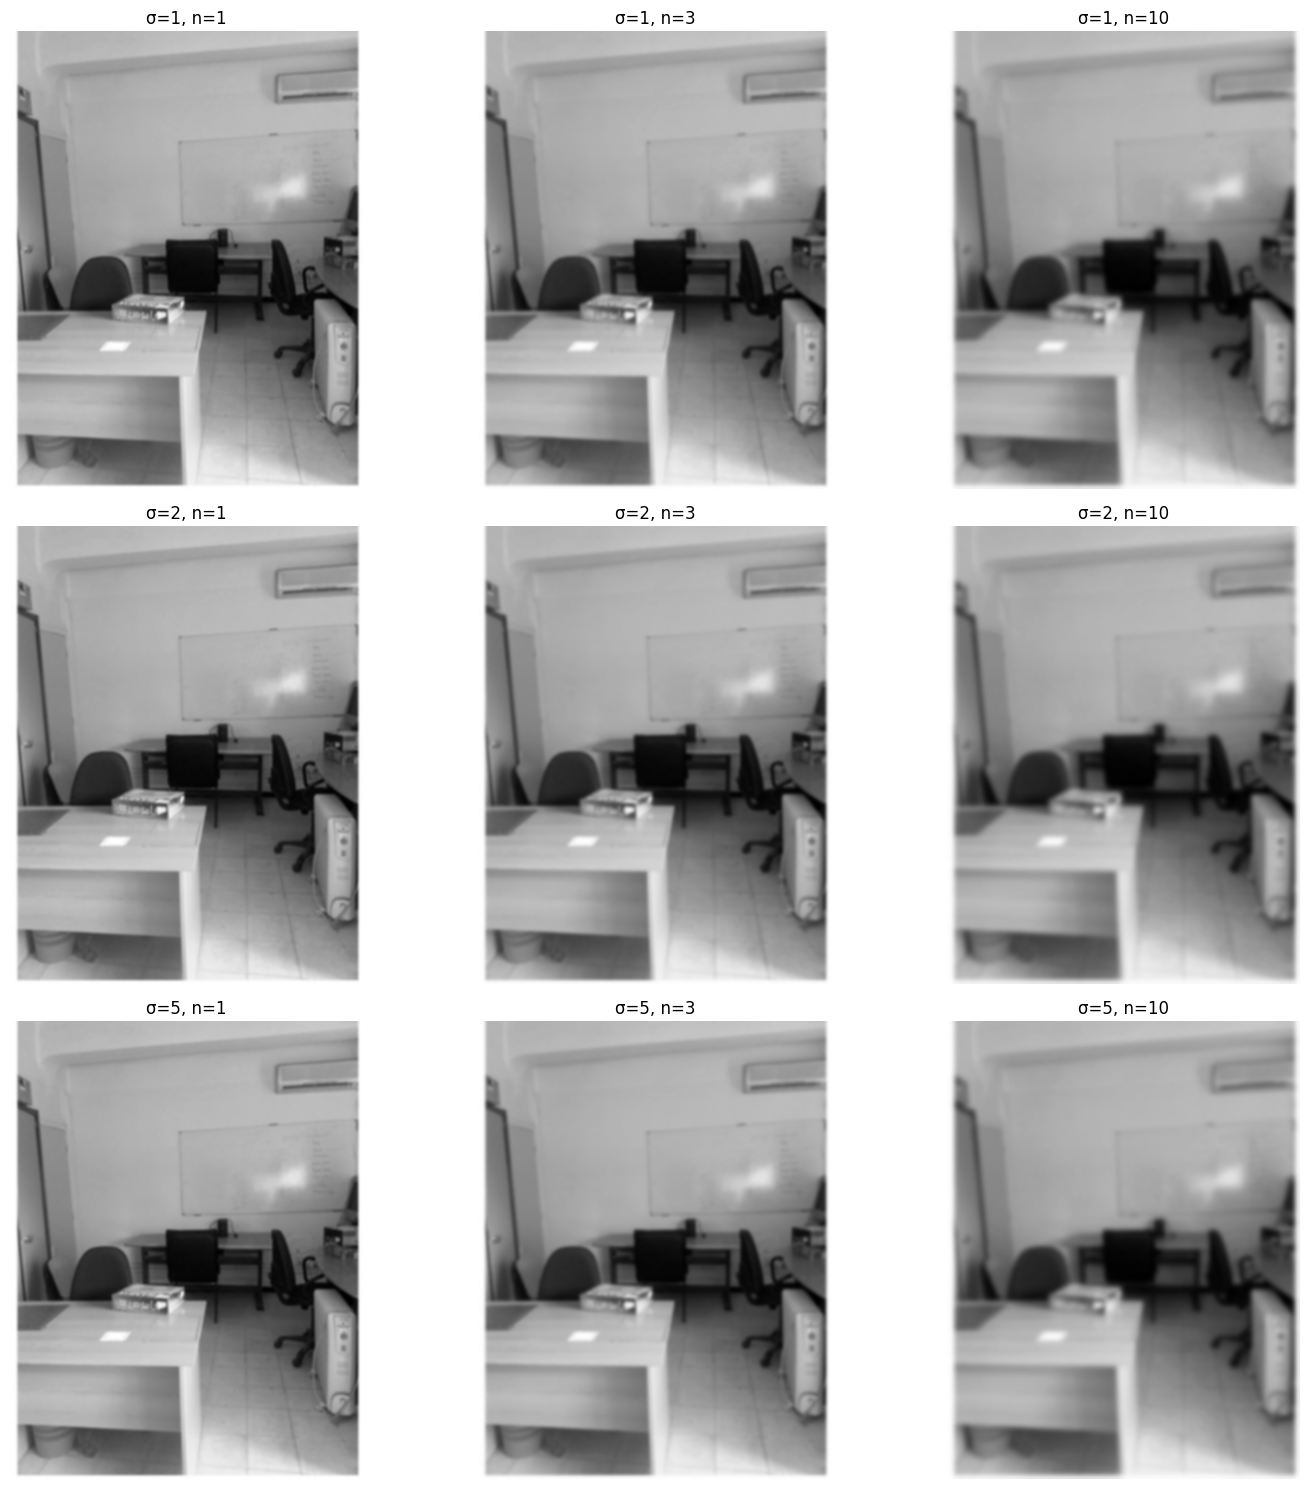

In [16]:
# Tester avec différentes valeurs
test_sigmas = [1, 2, 5]
test_n = [1, 3, 10]

fig, axes = plt.subplots(len(test_sigmas), len(test_n), figsize=(15, 15))

for i, test_sigma in enumerate(test_sigmas):
    for j, test_iterations in enumerate(test_n):
        # Application itérative
        g_test = cv2.GaussianBlur(image, kernel_size, test_sigma, 0, cv2.BORDER_DEFAULT)
        for _ in range(test_iterations):
            g_test = cv2.GaussianBlur(g_test, kernel_size, test_sigma, 0, cv2.BORDER_DEFAULT)
        
        # Affichage
        axes[i, j].imshow(g_test, cmap='gray')
        axes[i, j].set_title(f'σ={test_sigma}, n={test_iterations}', fontsize=12)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()